In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [ ]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
df = pd.read_csv('customer 1-EDa-prj1.csv')

In [ ]:
df.head()

,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date
0,1,56.0,67700.0,1019.145669,Female,South,31.0,Toys,12.501082,2022-05-01,2022-02-27
1,2,69.0,50200.0,252.214693,Male,North,27.0,Toys,14.402036,2022-03-14,2022-07-03
2,3,46.0,84000.0,354.742321,Male,East,25.0,Clothing,89.085761,2022-07-17,2022-04-13
3,4,32.0,42700.0,716.573913,Male,West,5.0,Electronics,98.800804,2022-07-09,2021-04-21
4,5,60.0,112300.0,1528.118235,Female,West,6.0,Clothing,28.893785,2021-04-21,2021-06-02


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3526 entries, 0 to 3525
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 3526 non-null   int64  
 1   age                         3520 non-null   float64
 2   income                      3520 non-null   float64
 3   purchase_amount             3520 non-null   float64
 4   gender                      3519 non-null   object 
 5   region                      3520 non-null   object 
 6   total_purchases             3520 non-null   float64
 7   preferred_product_category  3518 non-null   object 
 8   customer_loyalty_score      3521 non-null   float64
 9   signup_date                 3520 non-null   object 
 10  last_purchase_date          3520 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 303.1+ KB
None


In [ ]:
print(df.describe())

       customer_id          age        income  purchase_amount  \
count  3526.000000  3520.000000  3.520000e+03      3520.000000   
mean   1738.398469    49.116477  7.469136e+04      1358.011839   
std    1005.277859    20.667920  1.910293e+05     10258.540297   
min       1.000000   -20.000000 -5.000000e+04    -10000.000000   
25%     867.250000    33.000000  4.410000e+04       515.449662   
50%    1739.500000    49.000000  6.950000e+04      1008.401544   
75%    2608.750000    64.000000  9.590000e+04      1494.622453   
max    3476.000000   500.000000  9.999999e+06    500000.000000   

       total_purchases  customer_loyalty_score  
count      3520.000000             3521.000000  
mean         33.310227               62.114247  
std         264.613324              359.620617  
min       -1000.000000             -999.000000  
25%          13.000000               24.275087  
50%          24.000000               49.629709  
75%          37.000000               74.338581  
max       100

In [ ]:
missing_values = df.isnull().sum()

In [ ]:
missing_values

,0
customer_id,0
age,6
income,6
purchase_amount,6
gender,7
region,6
total_purchases,6
preferred_product_category,8
customer_loyalty_score,5
signup_date,6


In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100

In [ ]:
missing_percent

,0
customer_id,0.000000
age,0.170164
income,0.170164
purchase_amount,0.170164
gender,0.198525
region,0.170164
total_purchases,0.170164
preferred_product_category,0.226886
customer_loyalty_score,0.141804
signup_date,0.170164


In [ ]:
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
})

In [ ]:
missing_df

,Missing Count,Missing Percentage
customer_id,0,0.000000
age,6,0.170164
income,6,0.170164
purchase_amount,6,0.170164
gender,7,0.198525
region,6,0.170164
total_purchases,6,0.170164
preferred_product_category,8,0.226886
customer_loyalty_score,5,0.141804
signup_date,6,0.170164


In [ ]:
print(missing_df[missing_df['Missing Count'] > 0])

                            Missing Count  Missing Percentage
age                                     6            0.170164
income                                  6            0.170164
purchase_amount                         6            0.170164
gender                                  7            0.198525
region                                  6            0.170164
total_purchases                         6            0.170164
preferred_product_category              8            0.226886
customer_loyalty_score                  5            0.141804
signup_date                             6            0.170164
last_purchase_date                      6            0.170164


In [ ]:
print("\n=== DUPLICATE RECORDS ===")
print(f"Number of duplicate rows: {df.duplicated().sum()}")


=== DUPLICATE RECORDS ===
Number of duplicate rows: 50


In [ ]:
df['age'].unique()

array([ 56.,  69.,  46.,  32.,  60.,  25.,  78.,  38.,  75.,  36.,  40.,
        28.,  41.,  70.,  53.,  57.,  20.,  39.,  19.,  61.,  47.,  55.,
        77.,  50.,  29.,  42.,  66.,  44.,  76.,  59.,  45.,  33.,  79.,
        64.,  68.,  72.,  74.,  54.,  24.,  26.,  35.,  21.,  31.,  67.,
        43.,  37.,  52.,  34.,  23.,  71.,   0.,  51.,  27.,  48.,  65.,
        62.,  58.,  18.,  22.,  30.,  49., 300.,  73.,  63., -20.,  nan,
       500.,  -5., 160., 170., 250., 150., 180.])

In [ ]:
df_cleaned = df.dropna(subset = ['age'])

In [ ]:
df_cleaned['age'].unique()

array([ 56.,  69.,  46.,  32.,  60.,  25.,  78.,  38.,  75.,  36.,  40.,
        28.,  41.,  70.,  53.,  57.,  20.,  39.,  19.,  61.,  47.,  55.,
        77.,  50.,  29.,  42.,  66.,  44.,  76.,  59.,  45.,  33.,  79.,
        64.,  68.,  72.,  74.,  54.,  24.,  26.,  35.,  21.,  31.,  67.,
        43.,  37.,  52.,  34.,  23.,  71.,   0.,  51.,  27.,  48.,  65.,
        62.,  58.,  18.,  22.,  30.,  49., 300.,  73.,  63., -20., 500.,
        -5., 160., 170., 250., 150., 180.])

In [ ]:
print("\nInvalid values check:")
print(f"Invalid ages (<=0 or >120): {((df['age'] <= 0) | (df['age'] > 120)).sum()}")
print(f"Invalid incomes (<=0): {(df['income'] <= 0).sum()}")
print(f"Invalid purchase amounts (<=0): {(df['purchase_amount'] <= 0).sum()}")


Invalid values check:
Invalid ages (<=0 or >120): 10
Invalid incomes (<=0): 4
Invalid purchase amounts (<=0): 7


In [ ]:
print(f"Extreme loyalty scores: {(df['customer_loyalty_score'] < 0) | (df['customer_loyalty_score'] > 100).sum()}")

Extreme loyalty scores: 0       True
1       True
2       True
3       True
4       True
        ... 
3521    True
3522    True
3523    True
3524    True
3525    True
Name: customer_loyalty_score, Length: 3526, dtype: bool


In [ ]:
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'], errors='coerce')

In [ ]:
categorical_cols = ['gender', 'region', 'preferred_product_category']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts())
        print(f"Missing values in {col}: {df[col].isnull().sum()}")


gender:
gender
Male          1784
Female        1726
Non-binary       1
Null             1
Unknown          1
123              1
0                1
                 1
999              1
Invalid          1
Alien            1
Name: count, dtype: int64
Missing values in gender: 7

region:
region
West        916
South       908
North       848
East        838
Invalid       1
Unknown       1
Space         1
Void          1
Moon          1
Pluto         1
123           1
Atlantis      1
Test          1
Mars          1
Name: count, dtype: int64
Missing values in region: 6

preferred_product_category:
preferred_product_category
Clothing         735
Electronics      729
Health           688
Home & Garden    686
Toys             671
Space              2
Test               1
Alien              1
Invalid            1
Unknown            1
Food               1
Null               1
999                1
Name: count, dtype: int64
Missing values in preferred_product_category: 8


In [228]:
df = pd.read_csv('customer 1-EDa-prj1.csv')

In [229]:
invalid_ages = df[(df['age'] < 18) | (df['age'] > 100) | (df['age'].isnull())]
print(f"Invalid ages (<18 or >100 or null): {len(invalid_ages)}")

Invalid ages (<18 or >100 or null): 16


In [230]:
# Create a mask for all valid ages.
# Note the use of `~` (tilde) to select non-null values.
age = (df['age'] >= 18) & (df['age'] <= 80) & (df['age'].notna())

# Filter the DataFrame to keep only the rows with valid ages.
df = df[age]

# Optional: Reset the index of the new DataFrame
df = df.reset_index(drop=True)

# Print the number of rows remaining to confirm
print(f"Number of rows with valid ages: {len(df)}")


Number of rows with valid ages: 3510


In [231]:
df

,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date
0,1,56.0,67700.0,1019.145669,Female,South,31.0,Toys,12.501082,2022-05-01,2022-02-27
1,2,69.0,50200.0,252.214693,Male,North,27.0,Toys,14.402036,2022-03-14,2022-07-03
2,3,46.0,84000.0,354.742321,Male,East,25.0,Clothing,89.085761,2022-07-17,2022-04-13
3,4,32.0,42700.0,716.573913,Male,West,5.0,Electronics,98.800804,2022-07-09,2021-04-21
4,5,60.0,112300.0,1528.118235,Female,West,6.0,Clothing,28.893785,2021-04-21,2021-06-02
...,...,...,...,...,...,...,...,...,...,...,...
3505,983,42.0,37500.0,1501.071832,Male,East,16.0,Electronics,2.403770,2021-04-02,2023-07-27
3506,1078,31.0,110800.0,1042.922632,Male,East,23.0,Electronics,72.893301,2022-09-22,2023-04-25
3507,956,77.0,108600.0,1713.991224,Female,West,37.0,Electronics,23.945481,2022-08-16,2021-04-30
3508,1326,43.0,32200.0,1693.124230,Male,North,35.0,Toys,6.470420,2021-03-25,2021-11-20


In [232]:
valid_income_mask = (df['income'] >= 20000) & (df['income'] <= 120000)

# Filter the DataFrame to keep only the rows with valid income values.
df = df[valid_income_mask]

# Optional: Reset the index after filtering.
df = df.reset_index(drop=True)

# Print the number of remaining rows to confirm the change.
print(f"Number of rows with valid income: {len(df)}")

Number of rows with valid income: 3494


In [233]:
df

,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date
0,1,56.0,67700.0,1019.145669,Female,South,31.0,Toys,12.501082,2022-05-01,2022-02-27
1,2,69.0,50200.0,252.214693,Male,North,27.0,Toys,14.402036,2022-03-14,2022-07-03
2,3,46.0,84000.0,354.742321,Male,East,25.0,Clothing,89.085761,2022-07-17,2022-04-13
3,4,32.0,42700.0,716.573913,Male,West,5.0,Electronics,98.800804,2022-07-09,2021-04-21
4,5,60.0,112300.0,1528.118235,Female,West,6.0,Clothing,28.893785,2021-04-21,2021-06-02
...,...,...,...,...,...,...,...,...,...,...,...
3489,983,42.0,37500.0,1501.071832,Male,East,16.0,Electronics,2.403770,2021-04-02,2023-07-27
3490,1078,31.0,110800.0,1042.922632,Male,East,23.0,Electronics,72.893301,2022-09-22,2023-04-25
3491,956,77.0,108600.0,1713.991224,Female,West,37.0,Electronics,23.945481,2022-08-16,2021-04-30
3492,1326,43.0,32200.0,1693.124230,Male,North,35.0,Toys,6.470420,2021-03-25,2021-11-20


In [234]:
purchase_amount_mask = (df['purchase_amount'] >= 20) & (df['purchase_amount'] <= 2000)

# Filter the DataFrame to keep only the rows with valid income values.
df = df[purchase_amount_mask]

# Optional: Reset the index after filtering.
df = df.reset_index(drop=True)

# Print the number of remaining rows to confirm the change.
print(f"Number of rows with valid income: {len(df)}")

Number of rows with valid income: 3468


In [235]:
df['purchase_amount'].count()

np.int64(3468)

In [236]:
# Create a list of the valid gender values
valid_genders = ['Male', 'Female']

# Filter the DataFrame to keep only rows where the gender is in the list
df = df[df['gender'].isin(valid_genders)]

# Optional: Print the number of rows remaining to verify the change
print(f"Number of rows with valid gender: {len(df)}")

Number of rows with valid gender: 3452


In [237]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [238]:
# Create a list of the valid region values
valid_regions = ['North', 'South', 'East', 'West']

# Filter the DataFrame, keeping only rows where the 'region' is in the list
df = df[df['region'].isin(valid_regions)]

# Optional: Reset the index of the new DataFrame
df = df.reset_index(drop=True)

# Print the number of rows remaining
print(f"Number of rows with valid regions: {len(df)}")


Number of rows with valid regions: 3436


In [239]:
df['region'].unique()

array(['South', 'North', 'East', 'West'], dtype=object)

In [240]:
# Define the valid range
min_purchases = 1
max_purchases = 50

# Create a boolean mask to identify valid purchases.
# We check if 'total_purchases' is greater than or equal to 1 AND
# less than or equal to 50.
valid_purchases_mask = (df['total_purchases'] >= min_purchases) & (df['total_purchases'] <= max_purchases)

# Filter the DataFrame to keep only the rows where the mask is True.
df = df[valid_purchases_mask]

# Optional: Reset the index of the filtered DataFrame for a clean, sequential index.
df = df.reset_index(drop=True)

# Print the number of remaining rows to confirm
print(f"Number of rows with valid total_purchases: {len(df)}")


Number of rows with valid total_purchases: 3420


In [241]:
df.isnull().sum()

,0
customer_id,0
age,0
income,0
purchase_amount,0
gender,0
region,0
total_purchases,0
preferred_product_category,7
customer_loyalty_score,5
signup_date,6


In [242]:
# Define a list of all valid categories
valid_categories = ['Electronics', 'Clothing', 'Home & Garden', 'Toys', 'Health']

# Filter the DataFrame to keep only the rows where 'preferred_product_category' is in the list
df = df[df['preferred_product_category'].isin(valid_categories)]

# Optional: Reset the index after filtering
df = df.reset_index(drop=True)

# Print the number of rows remaining to confirm
print(f"Number of rows with valid preferred product categories: {len(df)}")

Number of rows with valid preferred product categories: 3404


In [243]:
df['preferred_product_category'].unique()

array(['Toys', 'Clothing', 'Electronics', 'Home & Garden', 'Health'],
      dtype=object)

In [244]:
# Create a boolean mask to identify valid loyalty scores.
# The `&` operator is used for the logical AND condition.
valid_scores_mask = (df['customer_loyalty_score'] >= 0) & (df['customer_loyalty_score'] <= 100)

# Filter the DataFrame to keep only the rows with a valid loyalty score.
df = df[valid_scores_mask]

# Optional: Reset the index of the filtered DataFrame for a clean, sequential index.
df = df.reset_index(drop=True)

# Print the number of rows remaining to confirm
print(f"Number of rows with valid customer_loyalty_score: {len(df)}")


Number of rows with valid customer_loyalty_score: 3379


In [245]:
df.isnull().sum()

,0
customer_id,0
age,0
income,0
purchase_amount,0
gender,0
region,0
total_purchases,0
preferred_product_category,0
customer_loyalty_score,0
signup_date,6


In [246]:
import pandas as pd

# Assume your DataFrame is named df
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')


In [247]:
start_date = pd.to_datetime('2021-01-01')
end_date = pd.to_datetime('2022-12-31')


In [248]:
# Create a mask for valid signup dates
valid_date_mask = (df['signup_date'].notna()) & \
                  (df['signup_date'] >= start_date) & \
                  (df['signup_date'] <= end_date)

# Filter the DataFrame to keep only valid dates
df = df[valid_date_mask]

# Optional: Reset the index for a clean, sequential index
df = df.reset_index(drop=True)

# Print the number of remaining rows to confirm the change
print(f"Number of rows with valid signup dates: {len(df)}")


Number of rows with valid signup dates: 3373


In [249]:
df.isnull().sum()

,0
customer_id,0
age,0
income,0
purchase_amount,0
gender,0
region,0
total_purchases,0
preferred_product_category,0
customer_loyalty_score,0
signup_date,0


In [250]:
import pandas as pd


df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'], errors='coerce')
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')


valid_dates_mask = (df['last_purchase_date'].notna()) & \
                   (df['signup_date'].notna()) & \
                   (df['last_purchase_date'] > df['signup_date'])


df = df[valid_dates_mask]


df = df.reset_index(drop=True)


print(f"Number of rows with valid last purchase dates: {len(df)}")


Number of rows with valid last purchase dates: 2248


In [251]:
df.isnull().sum()

,0
customer_id,0
age,0
income,0
purchase_amount,0
gender,0
region,0
total_purchases,0
preferred_product_category,0
customer_loyalty_score,0
signup_date,0


Plotting the Graphs

In [254]:
sns.set_style("whitegrid")

In [255]:
numerical_features = ['age', 'income', 'purchase_amount', 'total_purchases', 'customer_loyalty_score']
print("Descriptive Statistics for Numerical Features:\n")
print(df[numerical_features].describe())
print("\n" + "="*50 + "\n")

Descriptive Statistics for Numerical Features:

               age         income  purchase_amount  total_purchases  \
count  2248.000000    2248.000000      2248.000000      2248.000000   
mean     48.337633   70312.944840       999.904353        24.613434   
std      17.767608   29006.619054       569.886561        14.228929   
min      18.000000   20200.000000        20.369326         1.000000   
25%      33.000000   44575.000000       526.179305        13.000000   
50%      48.000000   70000.000000       997.153421        24.000000   
75%      64.000000   96300.000000      1494.828576        37.000000   
max      79.000000  120000.000000      1999.508096        49.000000   

       customer_loyalty_score  
count             2248.000000  
mean                49.874240  
std                 28.809692  
min                  0.085729  
25%                 24.578672  
50%                 49.970233  
75%                 74.498006  
max                 99.935293  




In [256]:
categorical_features = ['gender', 'region', 'preferred_product_category']
for col in categorical_features:
    print(f"Value Counts for {col}:\n")
    print(df[col].value_counts())
    print("\n" + "-"*50 + "\n")

Value Counts for gender:

gender
Male      1137
Female    1111
Name: count, dtype: int64

--------------------------------------------------

Value Counts for region:

region
West     605
North    553
South    552
East     538
Name: count, dtype: int64

--------------------------------------------------

Value Counts for preferred_product_category:

preferred_product_category
Clothing         473
Electronics      469
Home & Garden    448
Toys             436
Health           422
Name: count, dtype: int64

--------------------------------------------------



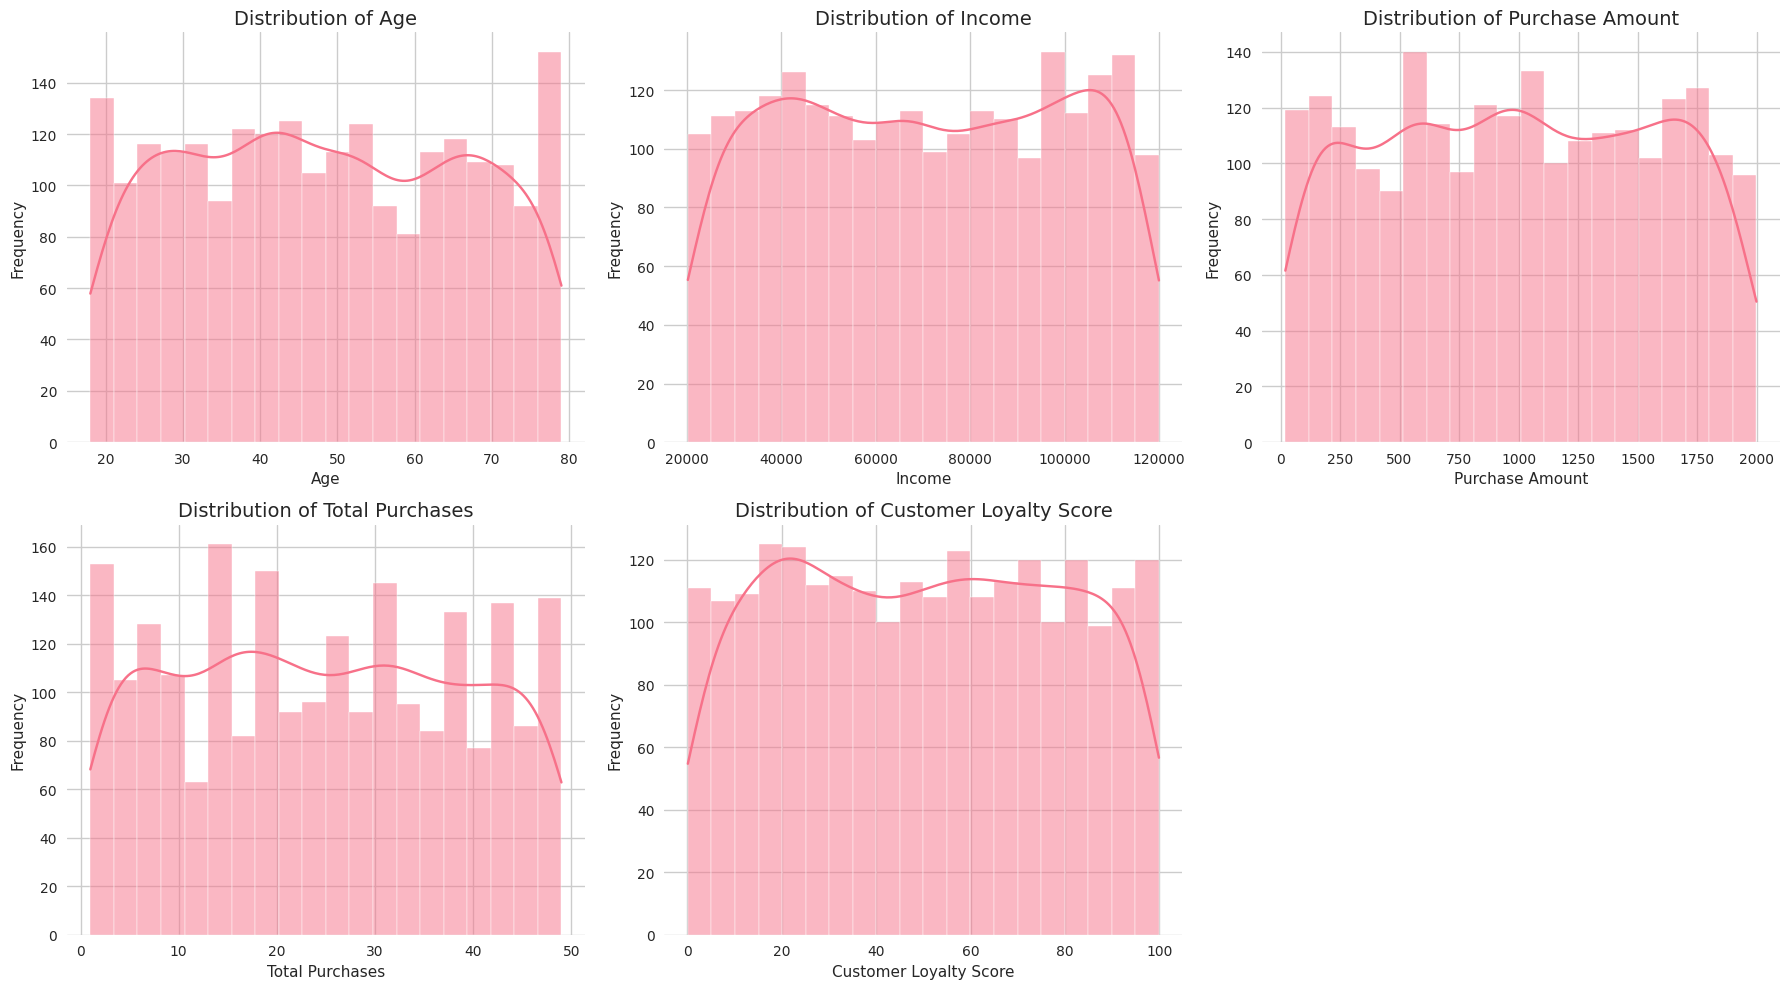

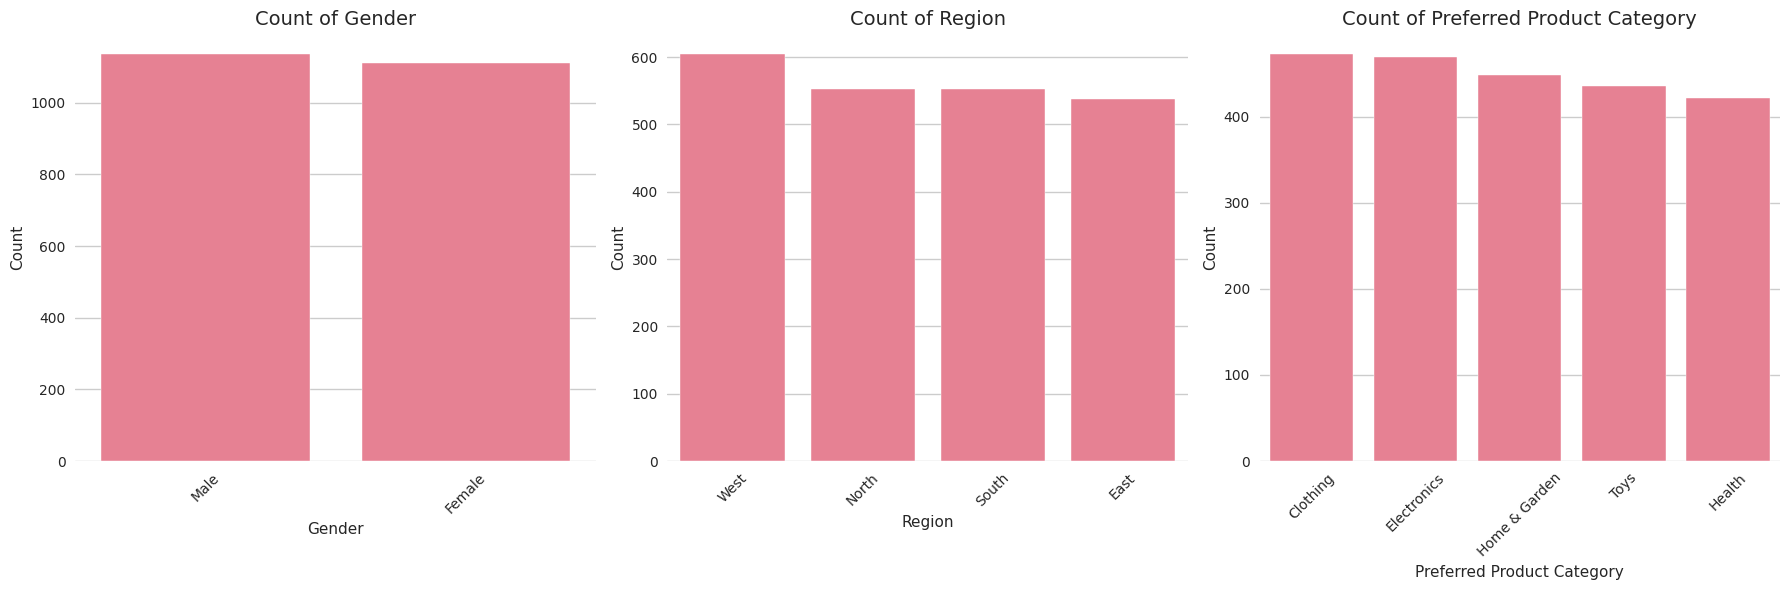

In [257]:
# Histograms for numerical features
# Create subplots for better organization
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

numerical_features = ['age', 'income', 'purchase_amount', 'total_purchases', 'customer_loyalty_score']
for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=20)
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=14)
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel("Frequency")

# Hide the last empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# Count plots for categorical features
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

categorical_features = ['gender', 'region', 'preferred_product_category']
for i, col in enumerate(categorical_features):
    sns.countplot(x=col, data=df, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Count of {col.replace("_", " ").title()}', fontsize=14)
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


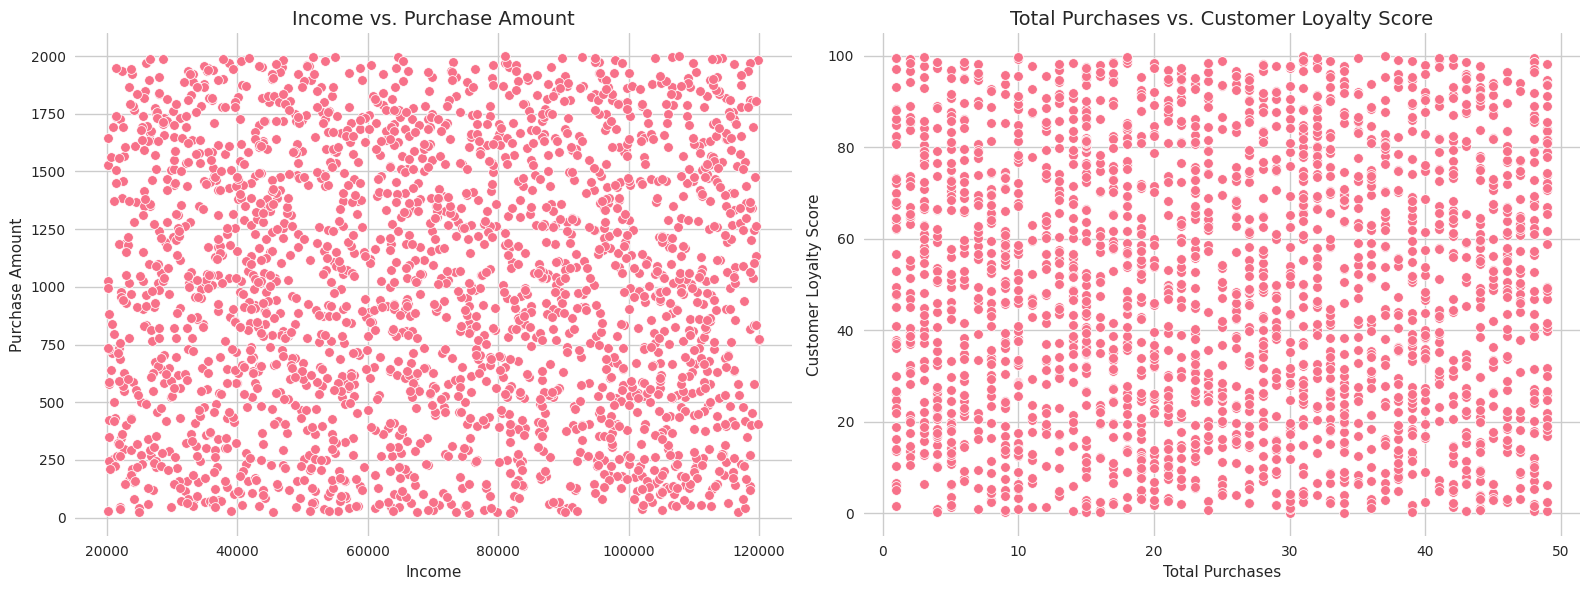

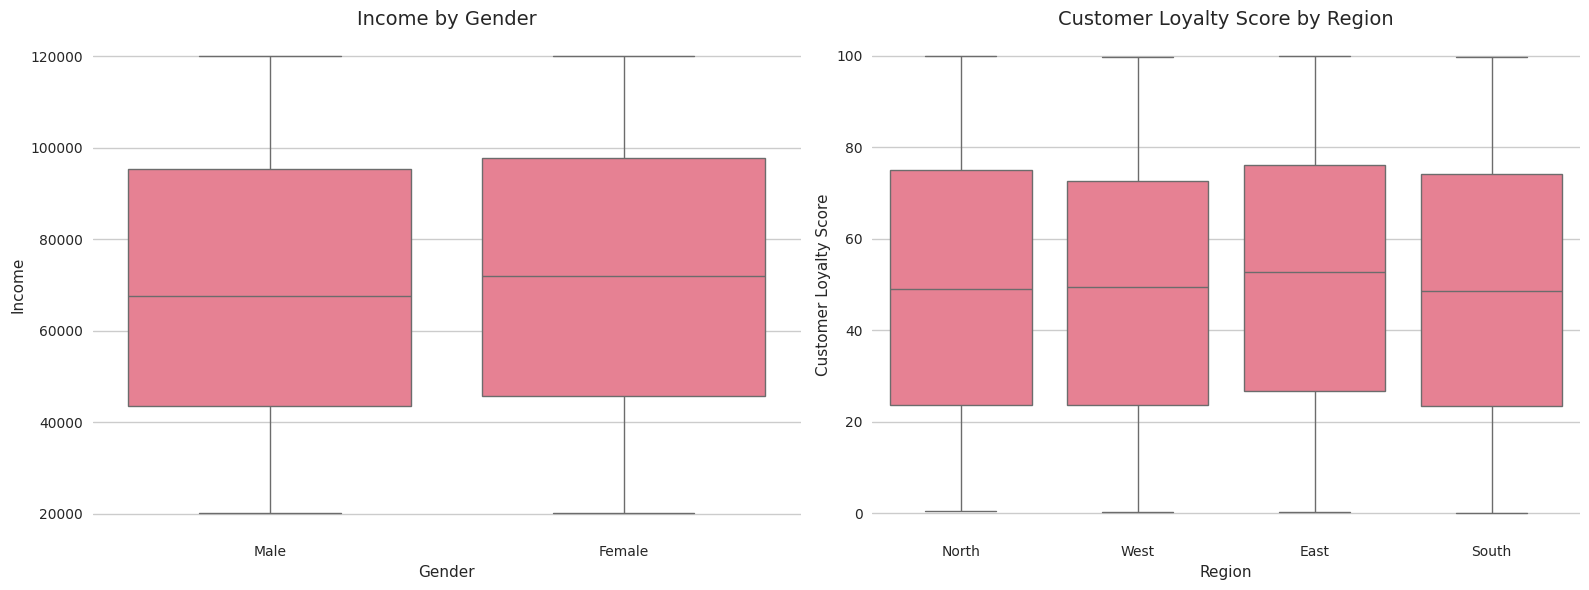

In [258]:
# Scatter plots for numerical relationships
# Examples: income vs. purchase_amount, total_purchases vs. loyalty_score
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Income vs. Purchase Amount
sns.scatterplot(x='income', y='purchase_amount', data=df, ax=axes[0])
axes[0].set_title('Income vs. Purchase Amount', fontsize=14)
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Purchase Amount')

# Total Purchases vs. Customer Loyalty Score
sns.scatterplot(x='total_purchases', y='customer_loyalty_score', data=df, ax=axes[1])
axes[1].set_title('Total Purchases vs. Customer Loyalty Score', fontsize=14)
axes[1].set_xlabel('Total Purchases')
axes[1].set_ylabel('Customer Loyalty Score')

plt.tight_layout()
plt.show()


# Box plots to compare a numerical feature across a categorical feature
# Example: income by gender and loyalty score by region
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Income by Gender
sns.boxplot(x='gender', y='income', data=df, ax=axes[0])
axes[0].set_title('Income by Gender', fontsize=14)
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Income')

# Loyalty Score by Region
sns.boxplot(x='region', y='customer_loyalty_score', data=df, ax=axes[1])
axes[1].set_title('Customer Loyalty Score by Region', fontsize=14)
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Customer Loyalty Score')

plt.tight_layout()
plt.show()


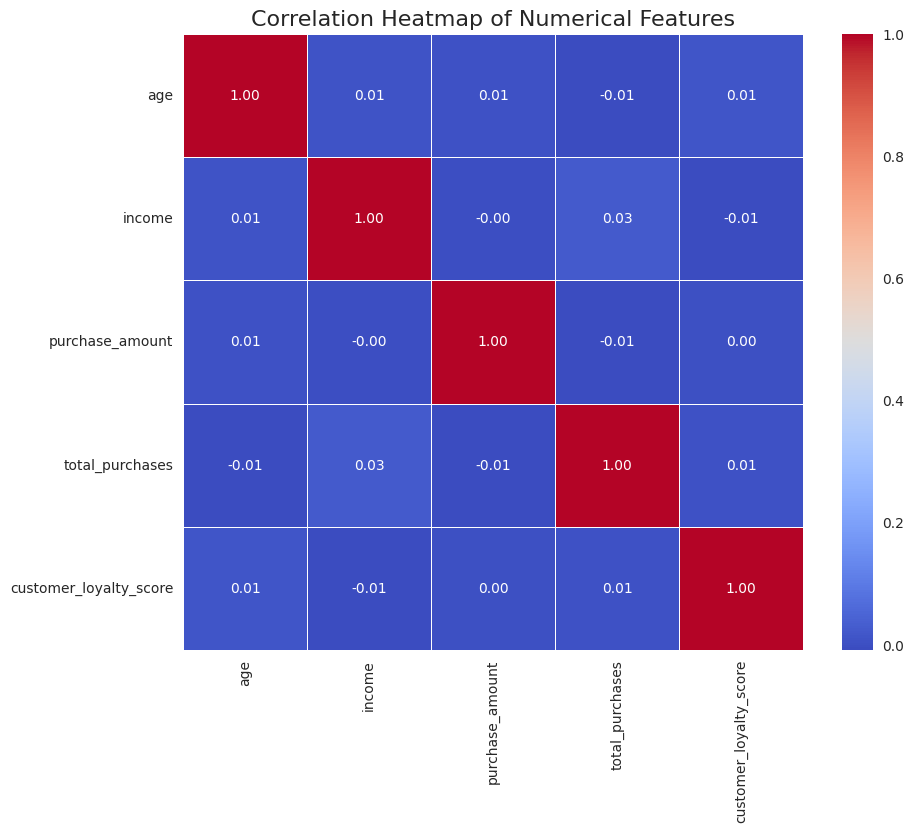

In [259]:
# Select only the numerical columns for correlation analysis
numerical_df = df[numerical_features]

# Compute the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()


In [260]:
df

,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date
0,2,69.0,50200.0,252.214693,Male,North,27.0,Toys,14.402036,2022-03-14,2022-07-03
1,5,60.0,112300.0,1528.118235,Female,West,6.0,Clothing,28.893785,2021-04-21,2021-06-02
2,6,25.0,62000.0,1024.023200,Male,West,5.0,Home & Garden,14.360273,2021-11-18,2023-07-06
3,7,78.0,90500.0,1283.045712,Female,East,27.0,Home & Garden,48.221228,2022-06-11,2023-02-01
4,8,38.0,81000.0,1970.645619,Male,East,8.0,Clothing,70.952806,2021-06-26,2022-12-21
...,...,...,...,...,...,...,...,...,...,...,...
2243,397,79.0,66800.0,1183.640096,Male,West,5.0,Toys,57.825385,2021-01-08,2021-12-05
2244,983,42.0,37500.0,1501.071832,Male,East,16.0,Electronics,2.403770,2021-04-02,2023-07-27
2245,1078,31.0,110800.0,1042.922632,Male,East,23.0,Electronics,72.893301,2022-09-22,2023-04-25
2246,1326,43.0,32200.0,1693.124230,Male,North,35.0,Toys,6.470420,2021-03-25,2021-11-20


In [261]:
df1 = df.copy()

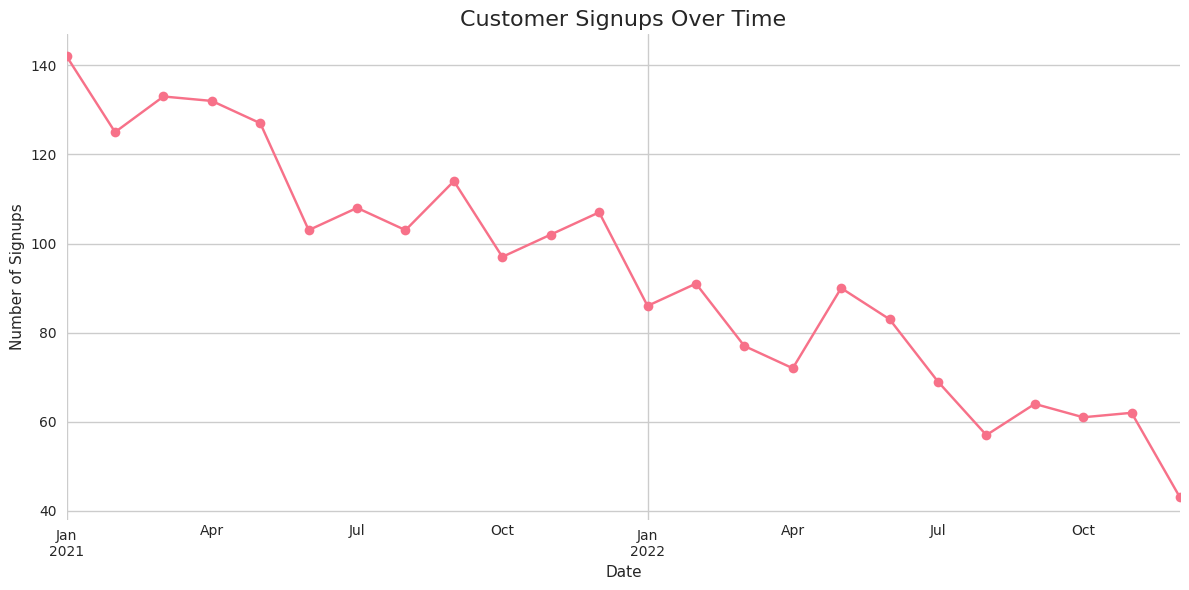

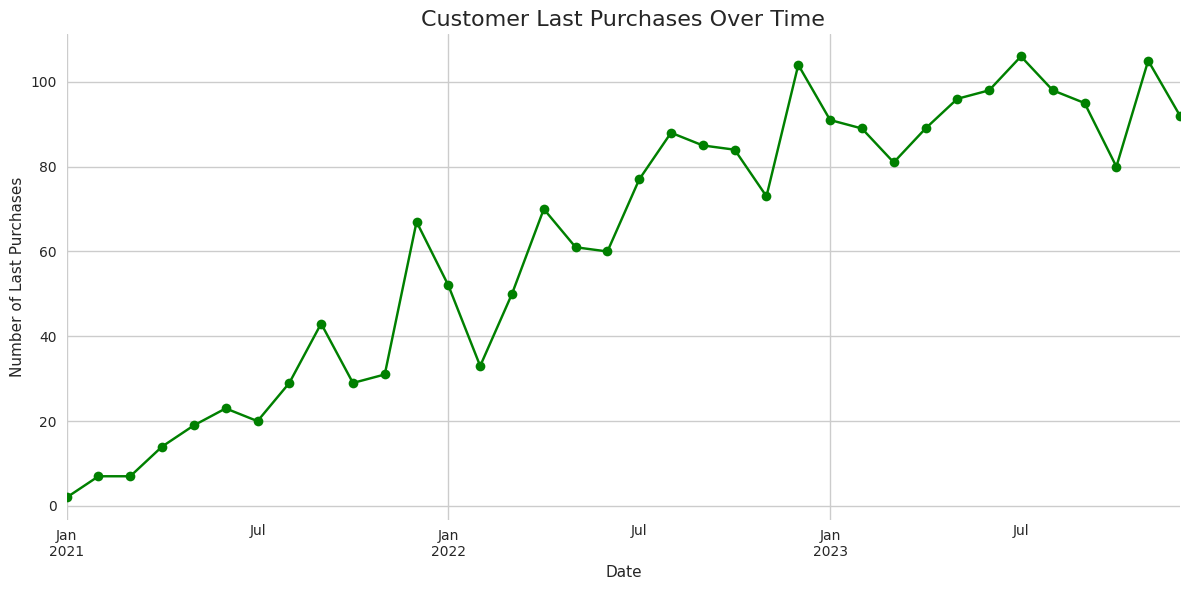

In [262]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

# ==============================================================================
# Analysis 1: Customer Signups Over Time
# ==============================================================================

# Create a temporary DataFrame for signup date analysis
df_signups = df.copy()

# Convert the signup_date column to datetime format
df_signups['signup_date'] = pd.to_datetime(df_signups['signup_date'], errors='coerce')

# Drop rows with invalid dates from the temporary DataFrame only
df_signups = df_signups.dropna(subset=['signup_date'])

# Set the date as the index for time-series analysis on the temporary DataFrame
df_signups.set_index('signup_date', inplace=True)

# Resample the data to count signups by month
monthly_signups = df_signups.resample('M').size()

# Plot the monthly signups
plt.figure(figsize=(12, 6))
monthly_signups.plot(kind='line', marker='o')
plt.title('Customer Signups Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Number of Signups')
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================================================================
# Analysis 2: Last Purchases Over Time
# ==============================================================================

# Create another temporary DataFrame for last purchase date analysis
df_purchases = df.copy()

# Convert the last_purchase_date column to datetime format
df_purchases['last_purchase_date'] = pd.to_datetime(df_purchases['last_purchase_date'], errors='coerce')

# Drop rows with invalid dates from the temporary DataFrame
df_purchases = df_purchases.dropna(subset=['last_purchase_date'])

# Set the date as the index for time-series analysis on the temporary DataFrame
df_purchases.set_index('last_purchase_date', inplace=True)

# Resample the data to count last purchases by month
monthly_purchases = df_purchases.resample('M').size()

# Plot the monthly last purchases
plt.figure(figsize=(12, 6))
monthly_purchases.plot(kind='line', marker='o', color='green')
plt.title('Customer Last Purchases Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Number of Last Purchases')
plt.grid(True)
plt.tight_layout()
plt.show()


In [263]:
df

,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date
0,2,69.0,50200.0,252.214693,Male,North,27.0,Toys,14.402036,2022-03-14,2022-07-03
1,5,60.0,112300.0,1528.118235,Female,West,6.0,Clothing,28.893785,2021-04-21,2021-06-02
2,6,25.0,62000.0,1024.023200,Male,West,5.0,Home & Garden,14.360273,2021-11-18,2023-07-06
3,7,78.0,90500.0,1283.045712,Female,East,27.0,Home & Garden,48.221228,2022-06-11,2023-02-01
4,8,38.0,81000.0,1970.645619,Male,East,8.0,Clothing,70.952806,2021-06-26,2022-12-21
...,...,...,...,...,...,...,...,...,...,...,...
2243,397,79.0,66800.0,1183.640096,Male,West,5.0,Toys,57.825385,2021-01-08,2021-12-05
2244,983,42.0,37500.0,1501.071832,Male,East,16.0,Electronics,2.403770,2021-04-02,2023-07-27
2245,1078,31.0,110800.0,1042.922632,Male,East,23.0,Electronics,72.893301,2022-09-22,2023-04-25
2246,1326,43.0,32200.0,1693.124230,Male,North,35.0,Toys,6.470420,2021-03-25,2021-11-20


In [264]:
df.to_excel('eda_cleaned_data.xlsx', index=False)

print("Data has been successfully saved to 'eda_cleaned_data.xlsx'")

Data has been successfully saved to 'eda_cleaned_data.xlsx'


In [265]:
df

,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date
0,2,69.0,50200.0,252.214693,Male,North,27.0,Toys,14.402036,2022-03-14,2022-07-03
1,5,60.0,112300.0,1528.118235,Female,West,6.0,Clothing,28.893785,2021-04-21,2021-06-02
2,6,25.0,62000.0,1024.023200,Male,West,5.0,Home & Garden,14.360273,2021-11-18,2023-07-06
3,7,78.0,90500.0,1283.045712,Female,East,27.0,Home & Garden,48.221228,2022-06-11,2023-02-01
4,8,38.0,81000.0,1970.645619,Male,East,8.0,Clothing,70.952806,2021-06-26,2022-12-21
...,...,...,...,...,...,...,...,...,...,...,...
2243,397,79.0,66800.0,1183.640096,Male,West,5.0,Toys,57.825385,2021-01-08,2021-12-05
2244,983,42.0,37500.0,1501.071832,Male,East,16.0,Electronics,2.403770,2021-04-02,2023-07-27
2245,1078,31.0,110800.0,1042.922632,Male,East,23.0,Electronics,72.893301,2022-09-22,2023-04-25
2246,1326,43.0,32200.0,1693.124230,Male,North,35.0,Toys,6.470420,2021-03-25,2021-11-20


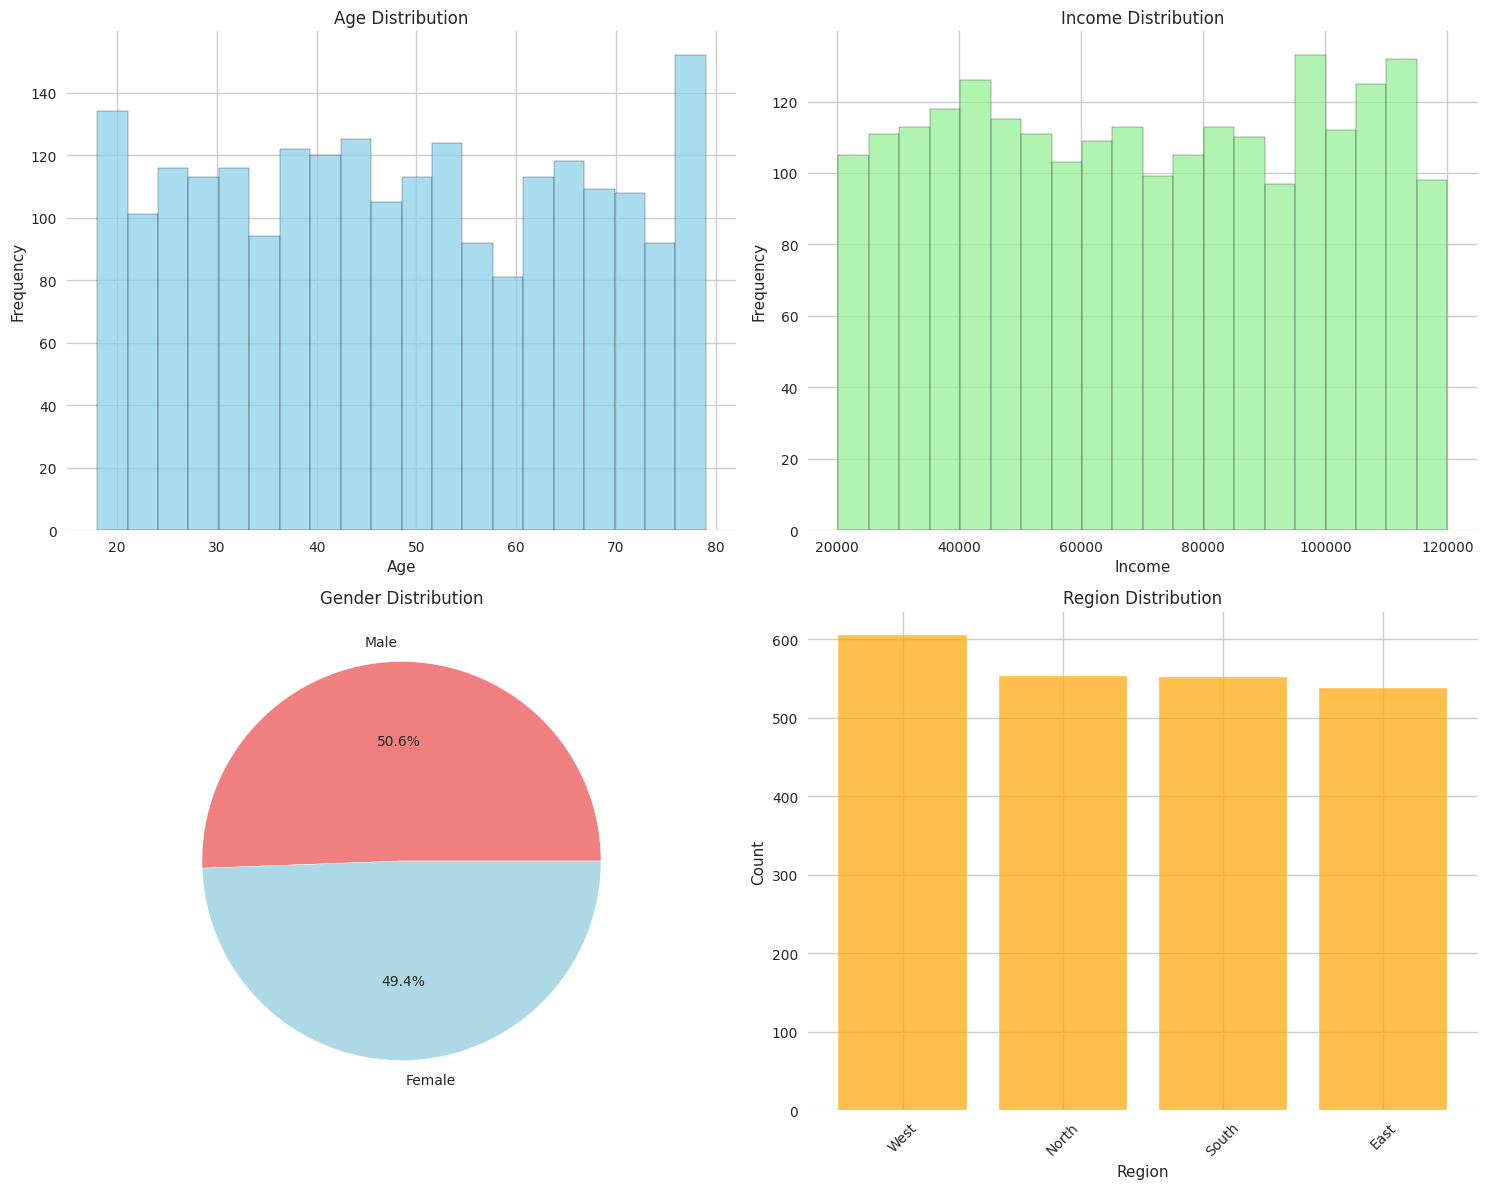

In [268]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0,0].hist(df11['age'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Age Distribution')


axes[0,1].hist(df11['income'], bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,1].set_xlabel('Income')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Income Distribution')


gender_counts = df11['gender'].value_counts()
axes[1,0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
axes[1,0].set_title('Gender Distribution')


region_counts = df11['region'].value_counts()
axes[1,1].bar(region_counts.index, region_counts.values, color='orange', alpha=0.7)
axes[1,1].set_xlabel('Region')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Region Distribution')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## EDA Analysis

In [273]:
df11 = pd.read_excel('eda_cleaned_data.xlsx')

In [274]:
df = df11.copy()

In [276]:
# Create age groups
def create_age_groups(age):
    if age <= 25:
        return '18-25'
    elif age <= 35:
        return '26-35'
    elif age <= 45:
        return '36-45'
    elif age <= 55:
        return '46-55'
    elif age <= 65:
        return '56-65'
    else:
        return '65+'

df['age_group'] = df['age'].apply(create_age_groups)

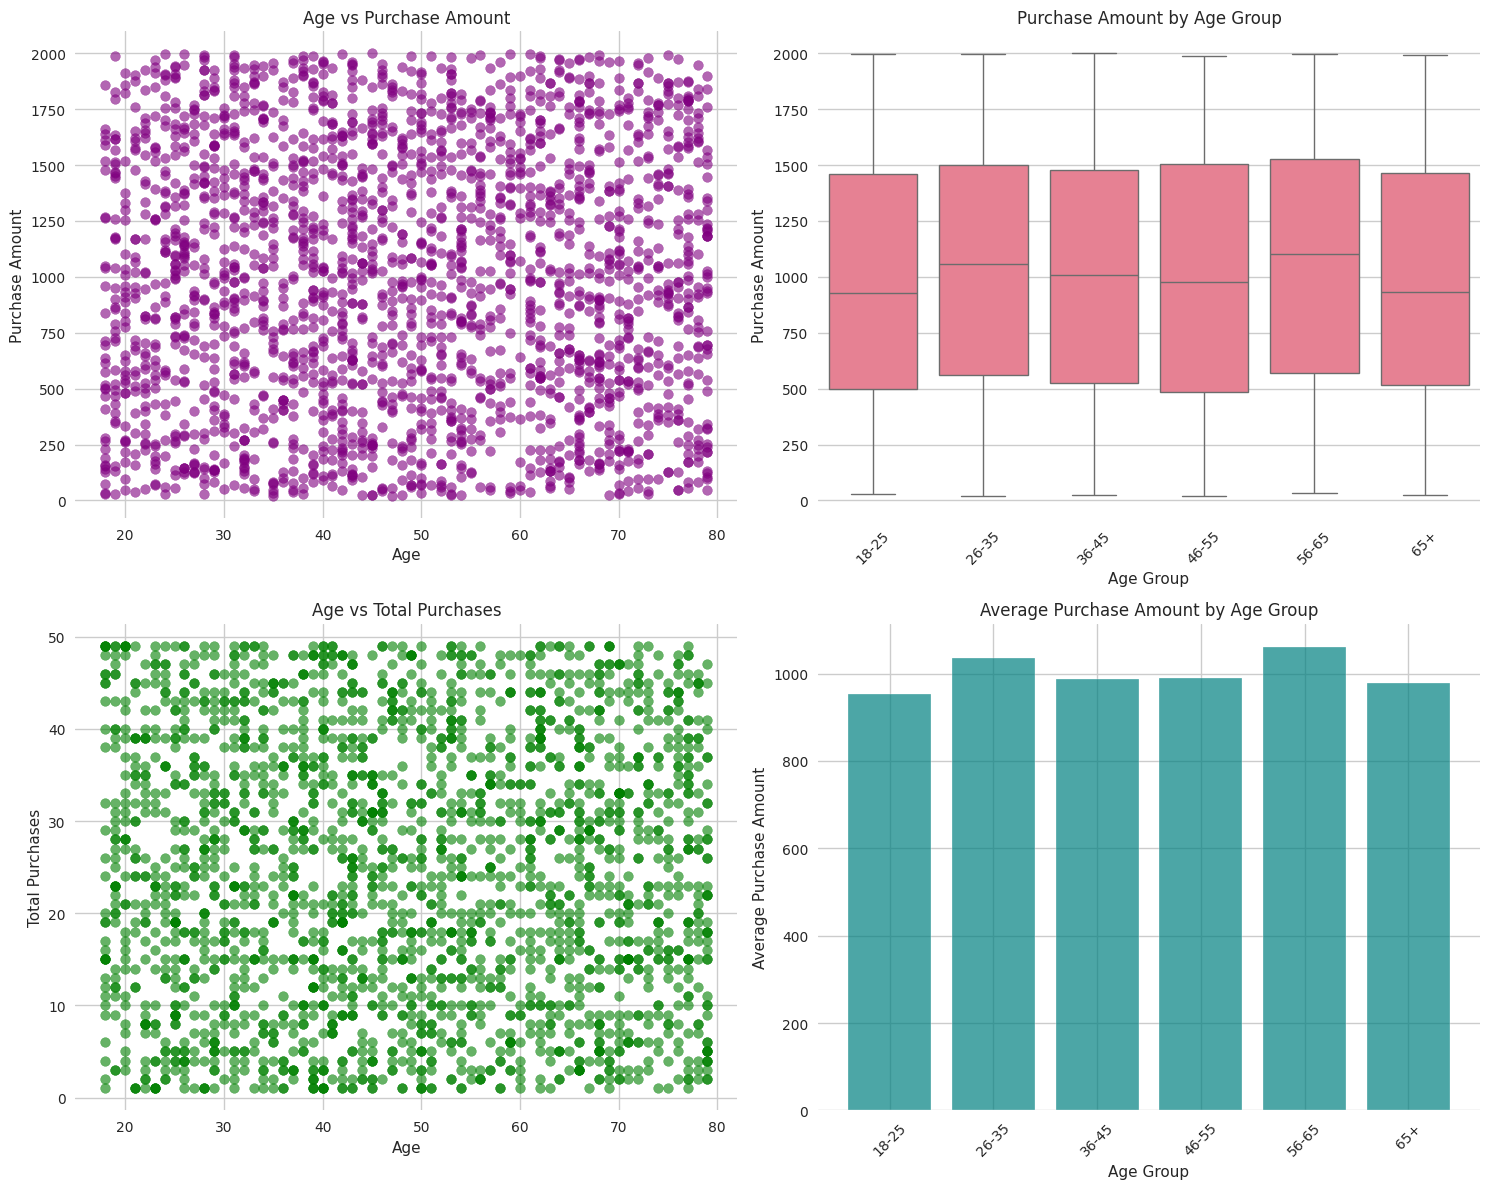


Statistical Summary by Age Group:
18-25: Mean = $953.45, Std = $564.96
26-35: Mean = $1035.13, Std = $578.22
36-45: Mean = $986.80, Std = $571.69
46-55: Mean = $990.80, Std = $571.87
56-65: Mean = $1060.86, Std = $561.26
65+: Mean = $978.01, Std = $567.41


In [280]:
# Age vs Purchase Amount
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot: Age vs Purchase Amount
axes[0,0].scatter(df['age'], df['purchase_amount'], alpha=0.6, color='purple')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Purchase Amount')
axes[0,0].set_title('Age vs Purchase Amount')

# Boxplot: Age Group vs Purchase Amount
age_group_order = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
sns.boxplot(data=df, x='age_group', y='purchase_amount', order=age_group_order, ax=axes[0,1])
axes[0,1].set_xlabel('Age Group')
axes[0,1].set_ylabel('Purchase Amount')
axes[0,1].set_title('Purchase Amount by Age Group')
axes[0,1].tick_params(axis='x', rotation=45)

# Age vs Total Purchases
axes[1,0].scatter(df['age'], df['total_purchases'], alpha=0.6, color='green')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Total Purchases')
axes[1,0].set_title('Age vs Total Purchases')

# Average purchase amount by age group
avg_purchase_by_age = df.groupby('age_group')['purchase_amount'].mean().reindex(age_group_order)
axes[1,1].bar(avg_purchase_by_age.index, avg_purchase_by_age.values, color='teal', alpha=0.7)
axes[1,1].set_xlabel('Age Group')
axes[1,1].set_ylabel('Average Purchase Amount')
axes[1,1].set_title('Average Purchase Amount by Age Group')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistical test for age groups
age_groups = df['age_group'].unique()
print("\nStatistical Summary by Age Group:")
for age_group in age_group_order:
    group_data = df[df['age_group'] == age_group]['purchase_amount']
    print(f"{age_group}: Mean = ${group_data.mean():.2f}, Std = ${group_data.std():.2f}")


In [281]:
df['income_group'] = pd.cut(df['income'],
                           bins=[0, 30000, 60000, 90000, 120000, float('inf')],
                           labels=['<30k', '30k-60k', '60k-90k', '90k-120k', '120k+'])


Metrics by Income Group:
              purchase_amount  total_purchases  customer_loyalty_score
income_group                                                          
<30k                   960.89            23.88                   50.48
30k-60k               1004.44            24.64                   50.51
60k-90k               1022.58            24.16                   49.63
90k-120k               986.42            25.23                   49.29
120k+                     NaN              NaN                     NaN


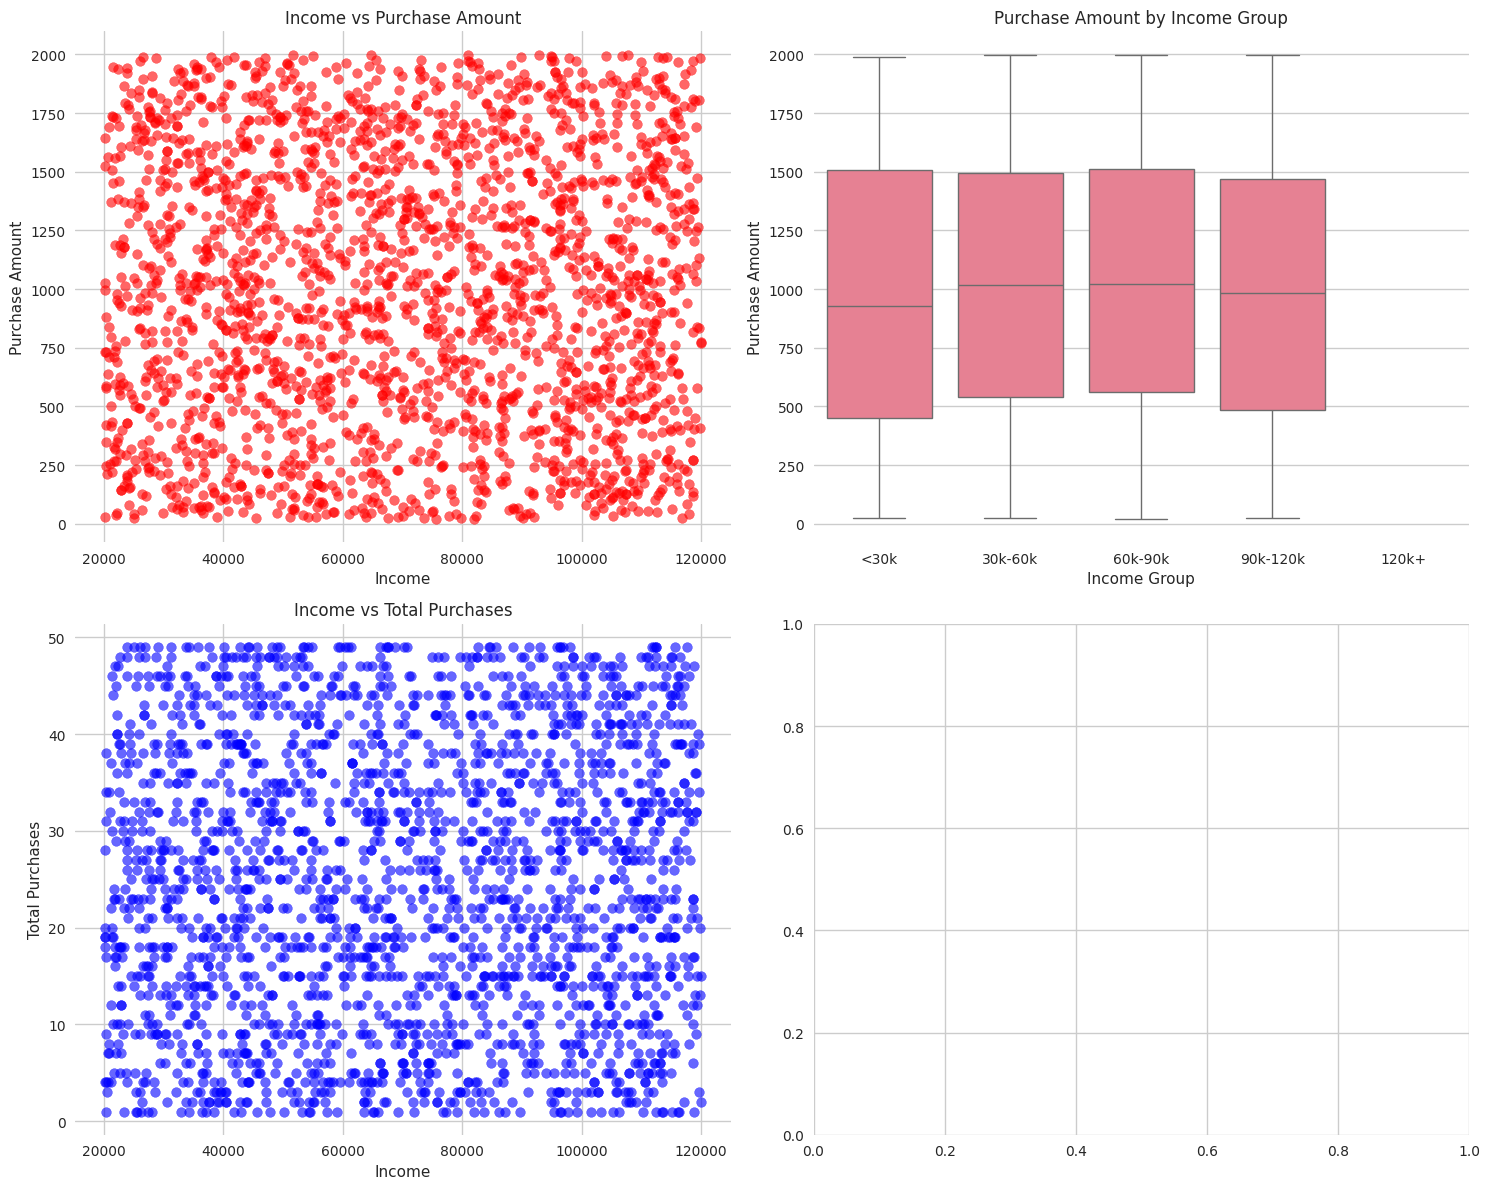


Correlation between Income and Purchase Amount: -0.002


In [282]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Income vs Purchase Amount scatter
axes[0,0].scatter(df['income'], df['purchase_amount'], alpha=0.6, color='red')
axes[0,0].set_xlabel('Income')
axes[0,0].set_ylabel('Purchase Amount')
axes[0,0].set_title('Income vs Purchase Amount')

# Income groups vs Purchase Amount
sns.boxplot(data=df, x='income_group', y='purchase_amount', ax=axes[0,1])
axes[0,1].set_xlabel('Income Group')
axes[0,1].set_ylabel('Purchase Amount')
axes[0,1].set_title('Purchase Amount by Income Group')

# Income vs Total Purchases
axes[1,0].scatter(df['income'], df['total_purchases'], alpha=0.6, color='blue')
axes[1,0].set_xlabel('Income')
axes[1,0].set_ylabel('Total Purchases')
axes[1,0].set_title('Income vs Total Purchases')

# Average metrics by income group
income_metrics = df.groupby('income_group').agg({
    'purchase_amount': 'mean',
    'total_purchases': 'mean',
    'customer_loyalty_score': 'mean'
}).round(2)

print("\nMetrics by Income Group:")
print(income_metrics)

plt.tight_layout()
plt.show()

# Correlation coefficient
income_purchase_corr = df['income'].corr(df['purchase_amount'])
print(f"\nCorrelation between Income and Purchase Amount: {income_purchase_corr:.3f}")

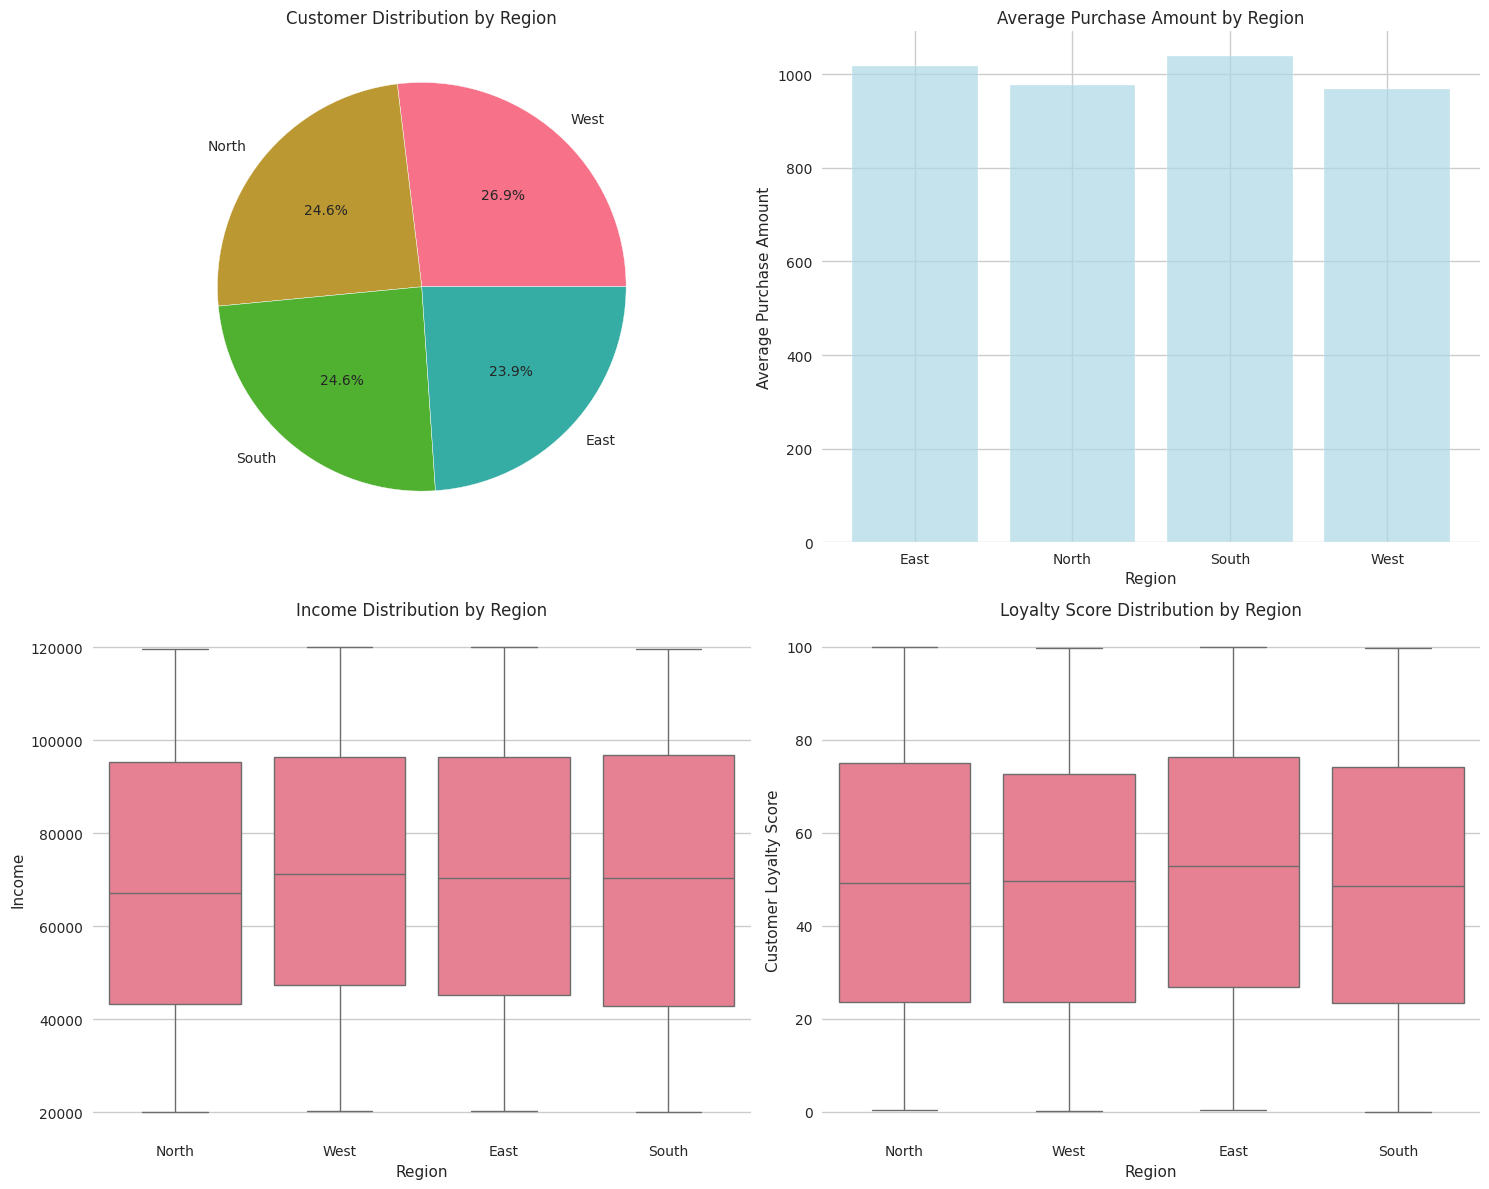


Regional Statistics:
       purchase_amount            income           customer_loyalty_score  \
                  mean     std      mean       std                   mean   
region                                                                      
East           1017.72  577.07  70318.59  29131.52                  52.10   
North           976.17  571.76  69330.74  29201.71                  49.67   
South          1039.85  563.06  70250.54  29576.52                  49.22   
West            969.31  566.54  71262.64  28222.01                  48.67   

              total_purchases         
          std            mean    std  
region                                
East    28.88           24.20  13.57  
North   28.61           25.52  14.28  
South   29.18           24.28  14.27  
West    28.56           24.45  14.71  


In [283]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Regional distribution of customers
region_counts = df['region'].value_counts()
axes[0,0].pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%')
axes[0,0].set_title('Customer Distribution by Region')

# Average purchase amount by region
avg_purchase_region = df.groupby('region')['purchase_amount'].mean()
axes[0,1].bar(avg_purchase_region.index, avg_purchase_region.values, color='lightblue', alpha=0.7)
axes[0,1].set_xlabel('Region')
axes[0,1].set_ylabel('Average Purchase Amount')
axes[0,1].set_title('Average Purchase Amount by Region')

# Regional income distribution
sns.boxplot(data=df, x='region', y='income', ax=axes[1,0])
axes[1,0].set_xlabel('Region')
axes[1,0].set_ylabel('Income')
axes[1,0].set_title('Income Distribution by Region')

# Regional loyalty scores
sns.boxplot(data=df, x='region', y='customer_loyalty_score', ax=axes[1,1])
axes[1,1].set_xlabel('Region')
axes[1,1].set_ylabel('Customer Loyalty Score')
axes[1,1].set_title('Loyalty Score Distribution by Region')

plt.tight_layout()
plt.show()

# Regional statistics
print("\nRegional Statistics:")
regional_stats = df.groupby('region').agg({
    'purchase_amount': ['mean', 'std'],
    'income': ['mean', 'std'],
    'customer_loyalty_score': ['mean', 'std'],
    'total_purchases': ['mean', 'std']
}).round(2)
print(regional_stats)

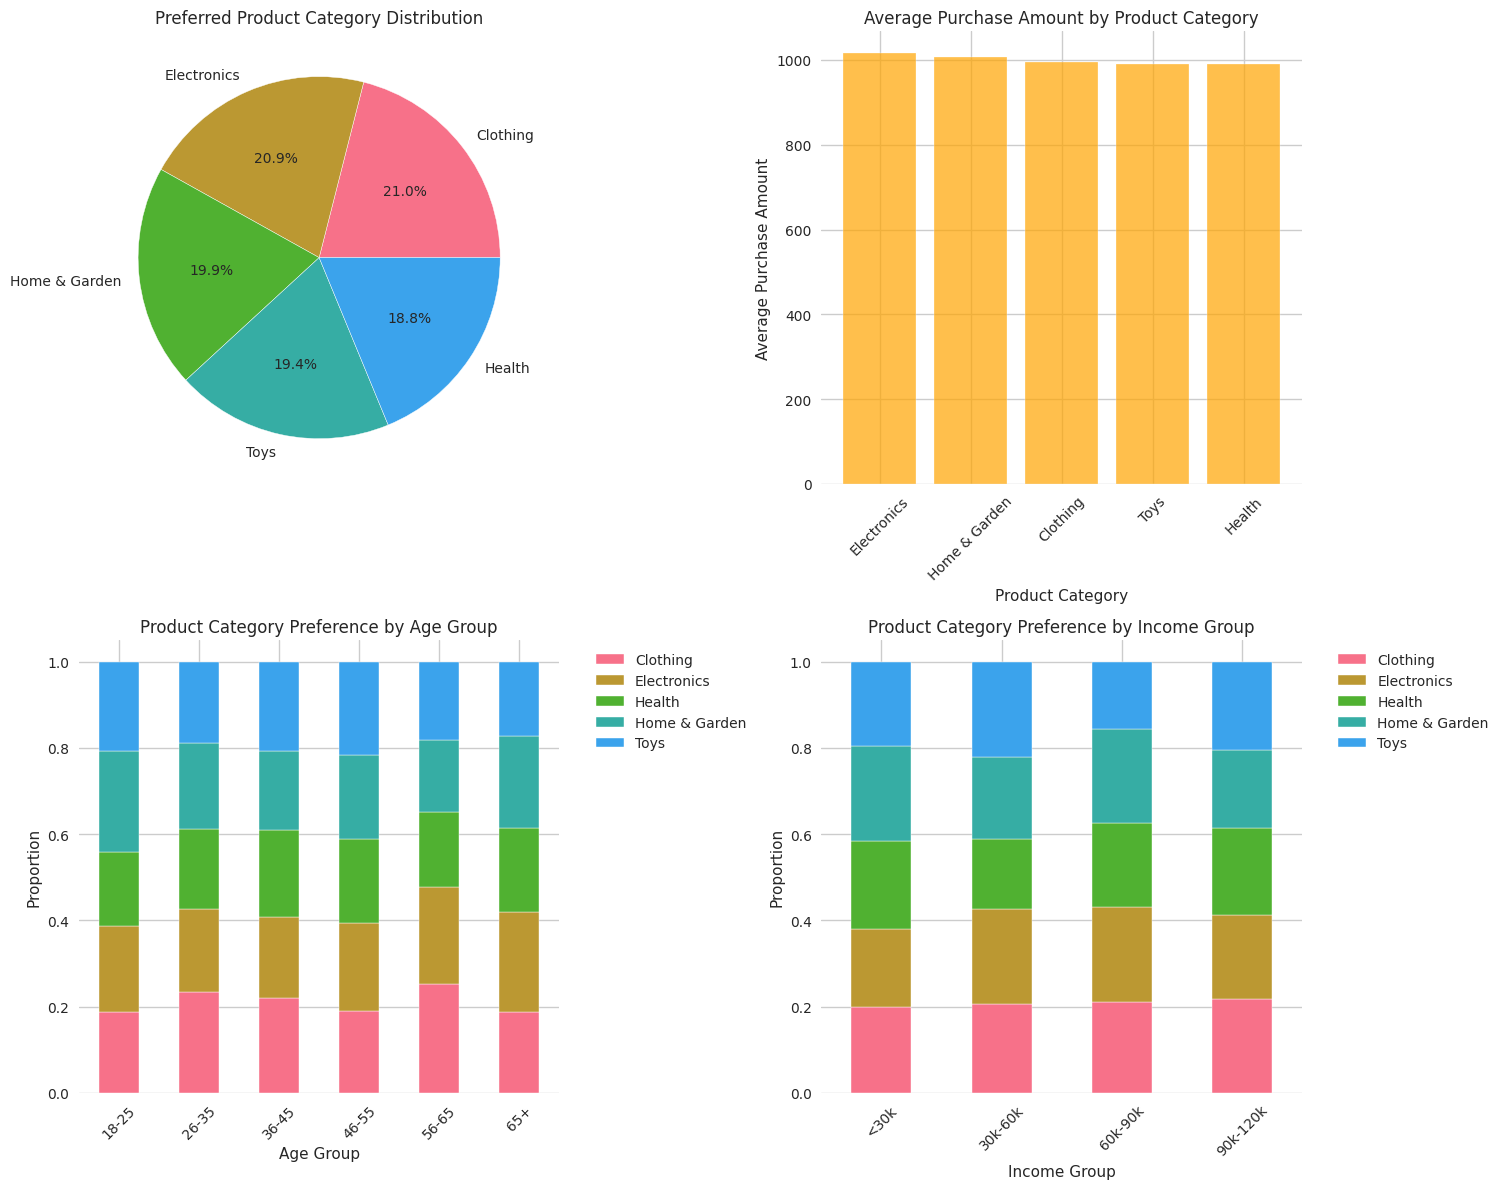


Product Category Statistics:
                           purchase_amount            income              age  \
                                      mean     std      mean       std   mean   
preferred_product_category                                                      
Clothing                            995.13  575.26  70920.93  29031.41  47.96   
Electronics                        1016.70  575.12  70395.31  28442.15  49.56   
Health                              989.41  566.75  72063.03  29051.29  48.55   
Home & Garden                      1007.07  569.77  68837.50  28522.02  48.11   
Toys                                989.81  563.59  69386.93  30035.03  47.47   

                                  total_purchases  
                              std            mean  
preferred_product_category                         
Clothing                    17.27           24.33  
Electronics                 17.89           23.17  
Health                      17.46           25.93  
Home & Ga

In [284]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Product category distribution
category_counts = df['preferred_product_category'].value_counts()
axes[0,0].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%')
axes[0,0].set_title('Preferred Product Category Distribution')

# Average purchase by category
avg_purchase_category = df.groupby('preferred_product_category')['purchase_amount'].mean().sort_values(ascending=False)
axes[0,1].bar(avg_purchase_category.index, avg_purchase_category.values, color='orange', alpha=0.7)
axes[0,1].set_xlabel('Product Category')
axes[0,1].set_ylabel('Average Purchase Amount')
axes[0,1].set_title('Average Purchase Amount by Product Category')
axes[0,1].tick_params(axis='x', rotation=45)

# Product category by age group
category_age = pd.crosstab(df['age_group'], df['preferred_product_category'], normalize='index')
category_age.plot(kind='bar', stacked=True, ax=axes[1,0])
axes[1,0].set_xlabel('Age Group')
axes[1,0].set_ylabel('Proportion')
axes[1,0].set_title('Product Category Preference by Age Group')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,0].tick_params(axis='x', rotation=45)

# Product category by income group
category_income = pd.crosstab(df['income_group'], df['preferred_product_category'], normalize='index')
category_income.plot(kind='bar', stacked=True, ax=axes[1,1])
axes[1,1].set_xlabel('Income Group')
axes[1,1].set_ylabel('Proportion')
axes[1,1].set_title('Product Category Preference by Income Group')
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Product category statistics
print("\nProduct Category Statistics:")
category_stats = df.groupby('preferred_product_category').agg({
    'purchase_amount': ['mean', 'std'],
    'income': ['mean', 'std'],
    'age': ['mean', 'std'],
    'total_purchases': 'mean'
}).round(2)
print(category_stats)

In [287]:
# Calculate customer tenure in days
df['customer_tenure_days'] = (df['last_purchase_date'] - df['signup_date']).dt.days

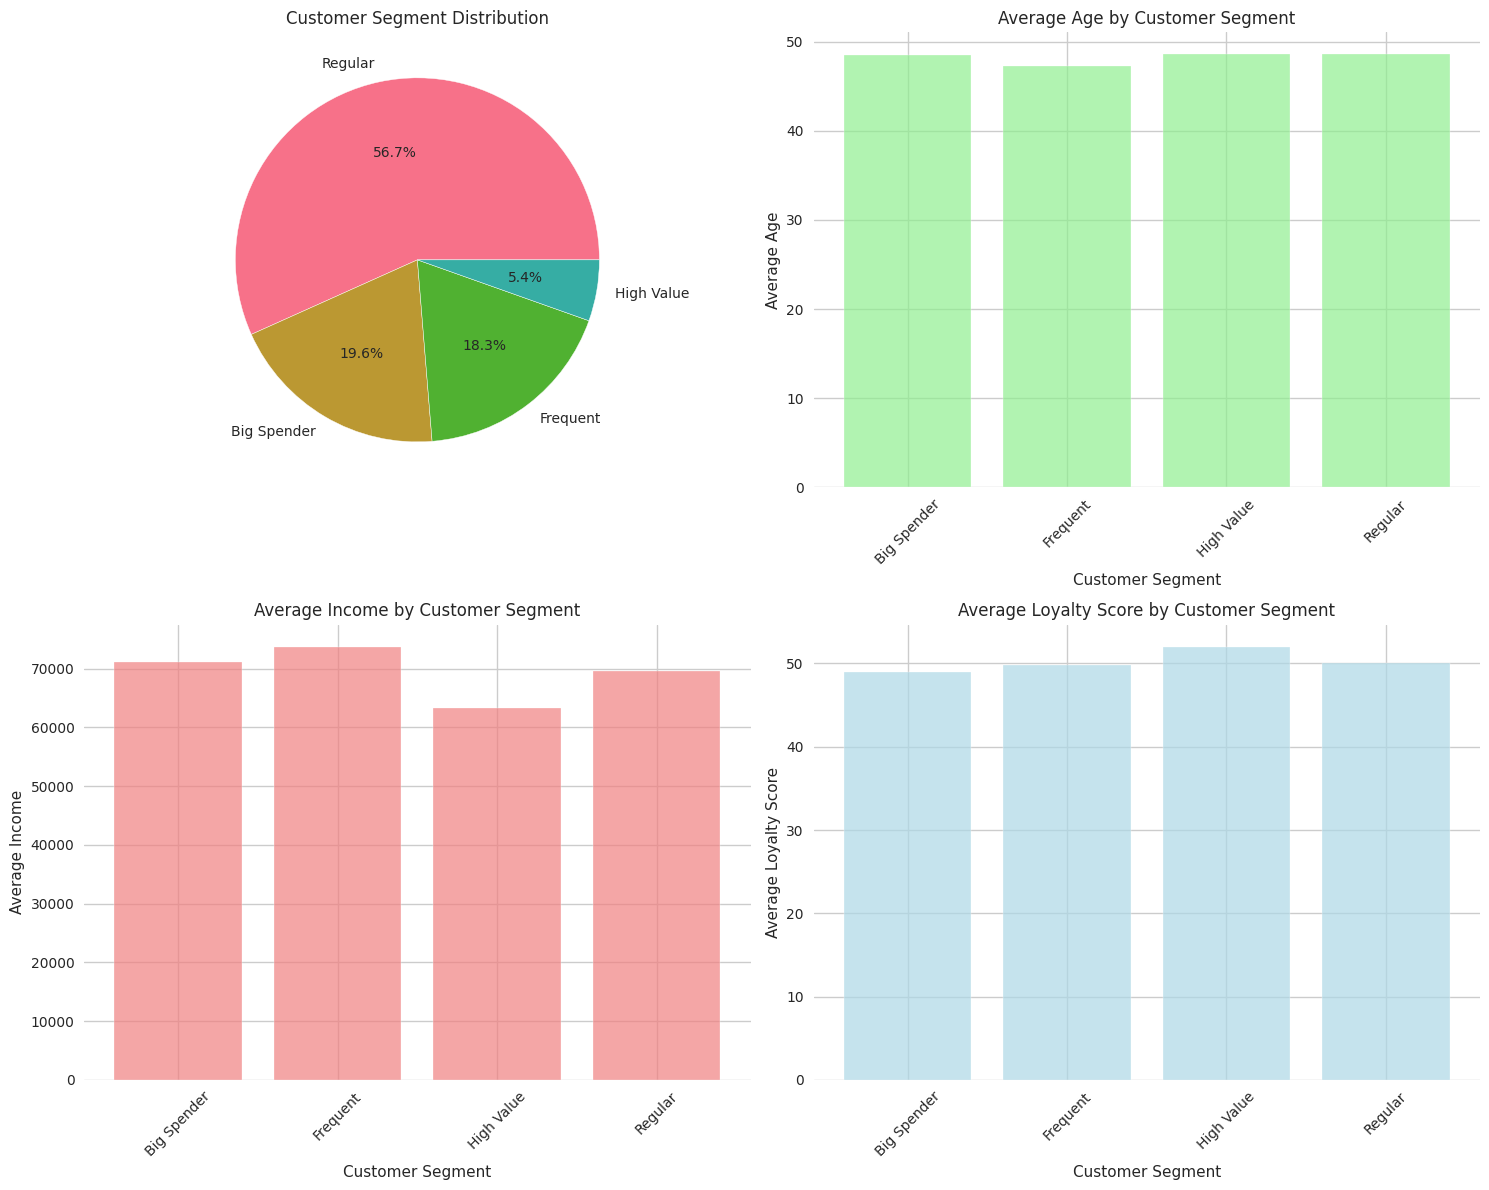


Customer Segment Statistics:
                    age    income  purchase_amount  total_purchases  \
customer_segment                                                      
Big Spender       48.49  71152.27          1740.18            18.85   
Frequent          47.28  73764.96           769.69            43.79   
High Value        48.60  63369.67          1740.34            43.11   
Regular           48.60  69574.90           747.80            18.65   

                  customer_loyalty_score  customer_tenure_days  
customer_segment                                                
Big Spender                        48.97                392.54  
Frequent                           49.83                410.15  
High Value                         52.03                382.29  
Regular                            49.99                389.81  


In [288]:
# Create customer segments based on spending behavior
def create_customer_segment(row):
    if row['total_purchases'] > df['total_purchases'].quantile(0.75) and row['purchase_amount'] > df['purchase_amount'].quantile(0.75):
        return 'High Value'
    elif row['total_purchases'] > df['total_purchases'].quantile(0.75):
        return 'Frequent'
    elif row['purchase_amount'] > df['purchase_amount'].quantile(0.75):
        return 'Big Spender'
    else:
        return 'Regular'

df['customer_segment'] = df.apply(create_customer_segment, axis=1)

# Segment analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Segment distribution
segment_counts = df['customer_segment'].value_counts()
axes[0,0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%')
axes[0,0].set_title('Customer Segment Distribution')

# Segment by age
segment_age = df.groupby('customer_segment')['age'].mean()
axes[0,1].bar(segment_age.index, segment_age.values, color='lightgreen', alpha=0.7)
axes[0,1].set_xlabel('Customer Segment')
axes[0,1].set_ylabel('Average Age')
axes[0,1].set_title('Average Age by Customer Segment')
axes[0,1].tick_params(axis='x', rotation=45)

# Segment by income
segment_income = df.groupby('customer_segment')['income'].mean()
axes[1,0].bar(segment_income.index, segment_income.values, color='lightcoral', alpha=0.7)
axes[1,0].set_xlabel('Customer Segment')
axes[1,0].set_ylabel('Average Income')
axes[1,0].set_title('Average Income by Customer Segment')
axes[1,0].tick_params(axis='x', rotation=45)

# Segment by loyalty
segment_loyalty = df.groupby('customer_segment')['customer_loyalty_score'].mean()
axes[1,1].bar(segment_loyalty.index, segment_loyalty.values, color='lightblue', alpha=0.7)
axes[1,1].set_xlabel('Customer Segment')
axes[1,1].set_ylabel('Average Loyalty Score')
axes[1,1].set_title('Average Loyalty Score by Customer Segment')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Segment statistics
print("\nCustomer Segment Statistics:")
segment_stats = df.groupby('customer_segment').agg({
    'age': 'mean',
    'income': 'mean',
    'purchase_amount': 'mean',
    'total_purchases': 'mean',
    'customer_loyalty_score': 'mean',
    'customer_tenure_days': 'mean'
}).round(2)
print(segment_stats)